## Analyse optimized mutation rate values

In [1]:
# --- make parent folder importable ---
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # points to Paper_SFS/

# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator, LogFormatter, FixedLocator, FuncFormatter
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import dask
import dask.dataframe as dd
import re
import dask.bag as db
import csv
from tqdm import tqdm
from dask.diagnostics import ProgressBar
from concurrent.futures import ProcessPoolExecutor
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json

# --- import your project modules (files in Paper_SFS/) ---
import Gen_SFS_with_s_demography
import plot_SFS


In [2]:
# get mutation rate mean, variance and weight p
def get_MR_values(demography, epoch , mu_low_mu = 2e-10):

    if demography == "NFE" or demography == "schraiber_et_al":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
    elif demography == "all":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_all.txt', sep = '\t')
    else:
        df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')

    mean_mus = df_mu_var_p['mean_mu'].values/(4*14448)
    var_mus = df_mu_var_p['var_mu'].values/((4*14448)**2)
    p_mus = df_mu_var_p['p_mu'].values

    adjusted_mean_mus = (1-p_mus) * mean_mus + p_mus * mu_low_mu
    adjusted_var_mus = (1-p_mus) * (var_mus + mean_mus**2) + p_mus * mu_low_mu**2 - (adjusted_mean_mus)**2

    return df_mu_var_p['MR'].values, adjusted_mean_mus, adjusted_var_mus, p_mus, df_mu_var_p['max_loglikelihood'].values

# ----------------------------------------------------------
# Fixed ancestry colors: consistent across all figures
# ----------------------------------------------------------
ANCESTRY_COLORS = {
    "NFE":     "#1f77b4",   # blue
    "AFR":     "#d62728",   # red
    "SAS":     "#9467bd",   # purple
    "EAS":     "#000000",   # black
    "AMR":     "#8c564b",   # brown-grey
    "FIN":     "#ff7f0e",   # orange
    "all":     "#2ca02c",   # green
    "de novo": "#FFC000"    # gold/yellow
}

def sci_fmt(x, pos):
    exp = int(np.floor(np.log10(x)))
    coeff = x / 10**exp
    return rf"${coeff:g}\times 10^{{{exp}}}$"

In [3]:
def plot_MR_demographies_fixed(demographies, epoch=3, figsize=(15, 4), alpha=1, s=25, fig_save_file=None, MR_cv_cutoff=0.211):
    """
    Plot mutation-rate parameters vs MR for multiple ancestries.

    CV panel:
    - Only MR > MR_cv_cutoff are shown
    - De novo CV shown as reference across all bins
    """

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    ax1, ax2, ax3 = axes

    # ---------------------------------------------------
    # Load de novo once (for CV reference)
    # ---------------------------------------------------
    df_mu_var_denovo = pd.read_csv("../Mutation_rate_estimation/param_mut_rate/results_mu_var_de_novo.csv")

    for demo in demographies:

        MR, mean_mu, var_mu, p_mu, ll = get_MR_values(demo, epoch=epoch)
        color = ANCESTRY_COLORS.get(demo, "#1f77b4")

        # -------------------------------
        # Panel 1: mean μ vs MR
        # -------------------------------
        ax1.scatter(MR, mean_mu,s=s,color=color,alpha=alpha, linewidth=0.4)#, label=demo)
        idx = np.argsort(MR)
        ax1.plot(MR[idx], mean_mu[idx], lw=1, color = color)
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ax1.tick_params(direction="out", length=5, width=1.2)

        # -------------------------------
        # Panel 2: CV vs mean μ
        # Only MR > cutoff
        # -------------------------------
        mask_cv = (MR > MR_cv_cutoff) & (MR < 3.5)
        if np.any(mask_cv):
            mean_mu_short = mean_mu[mask_cv]
            cv_short = (np.sqrt(var_mu) / mean_mu)[mask_cv]
            ax2.scatter(mean_mu_short, cv_short, s=s, color=color, alpha=alpha, label = demo)
            idx = np.argsort(mean_mu_short)
            ax2.plot(mean_mu_short[idx], cv_short[idx], lw=1, color = color)
            # ---------------------------------------------------
            # De novo CV reference (horizontal)
            # ---------------------------------------------------
            mu_dn_short = mean_mu[mask_cv]
            cv_dn_short = (df_mu_var_denovo["sigma_est"].values)[mask_cv] # (np.sqrt(df_mu_var_denovo["var_est"].values) / (mean_mu))[mask_cv]
            ax2.scatter(mu_dn_short, cv_dn_short, s=s, color=ANCESTRY_COLORS.get("de novo", "#1f77b4"), alpha=alpha, linewidth=0.4, label = "de novo")
            idx = np.argsort(mu_dn_short)
            ax2.plot(mu_dn_short[idx], cv_dn_short[idx], lw=1, color=ANCESTRY_COLORS.get("de novo", "#1f77b4"))
        ax2.set_ylim(0, 1.1)
        ax2.set_xscale("log")
        ax2.set_xlim(1e-8, 2.1e-7)
        major_ticks = np.array([1e-8, 5e-8, 1e-7])
        ax2.xaxis.set_major_locator(FixedLocator(major_ticks))
        minor_ticks = np.array([2e-8, 3e-8, 4e-8, 6e-8, 7e-8, 8e-8, 9e-8, 2e-7])
        ax2.xaxis.set_minor_locator(FixedLocator(minor_ticks))
        ax2.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
        ax2.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
        ax2.tick_params(axis="x", which="major", length=5, width=1.2)
        ax2.tick_params(axis="x", which="minor", length=3, width=0.6)
        
        # -------------------------------
        # Panel 3: p_mu vs mean μ
        # -------------------------------
        mask = (mean_mu>7e-8) & (mean_mu<1.75e-7) # (mean_mu>1.25e-7) & (mean_mu<3e-7)
        ax3.scatter(mean_mu[mask], p_mu[mask], s=s, color=color, alpha=alpha, linewidth=0.4, label = demo)
        ax3.set_yscale("log")
        ax3.set_xscale("log")
        ax3.set_xlim(7e-8, 1.75e-7)
        major_ticks = np.array([7e-8, 1e-7, 1.3e-7, 1.7e-7])
        ax3.xaxis.set_major_locator(FixedLocator(major_ticks))
        minor_ticks = np.array([8e-8, 9e-8, 1.1e-7, 1.2e-7, 1.4e-7, 1.5e-7, 1.6e-7, 1.8e-7])
        ax3.xaxis.set_minor_locator(FixedLocator(minor_ticks))
        ax3.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
        ax3.tick_params(axis="x", which="major", length=5, width=1.2)
        ax3.tick_params(axis="x", which="minor", length=3, width=0.6)

    # ---------------------------------------------------
    # Labels
    # ---------------------------------------------------
    ax1.set_xlabel("Roulette rate")
    ax1.set_ylabel("Mean mutation rate")

    ax2.set_xlabel("Mean mutation rate")
    ax2.set_ylabel("Coefficient of variation")

    ax3.set_xlabel("Mean mutation rate")
    ax3.set_ylabel(r"$p_{low}$")

    # ax1.legend(frameon=False, fontsize=12)
    ax2.legend(frameon=False, fontsize=11)

    plt.tight_layout()

    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format="svg")

    plt.show()


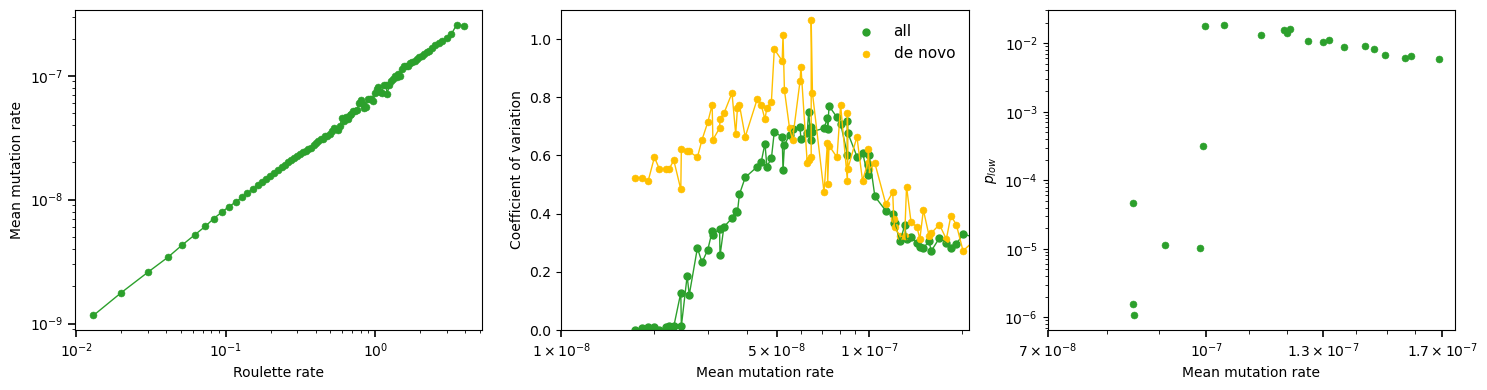

In [ ]:
# Plot the mean mutation rate, residual variance and p_mu as a function of Roulette for different ancestries individually

plot_MR_demographies_fixed(demographies=["NFE"], epoch = 3, fig_save_file="../Figures/NFE_mut_dist.svg")  # "AMR", "FIN", "SAS", "EAS", "AFR"

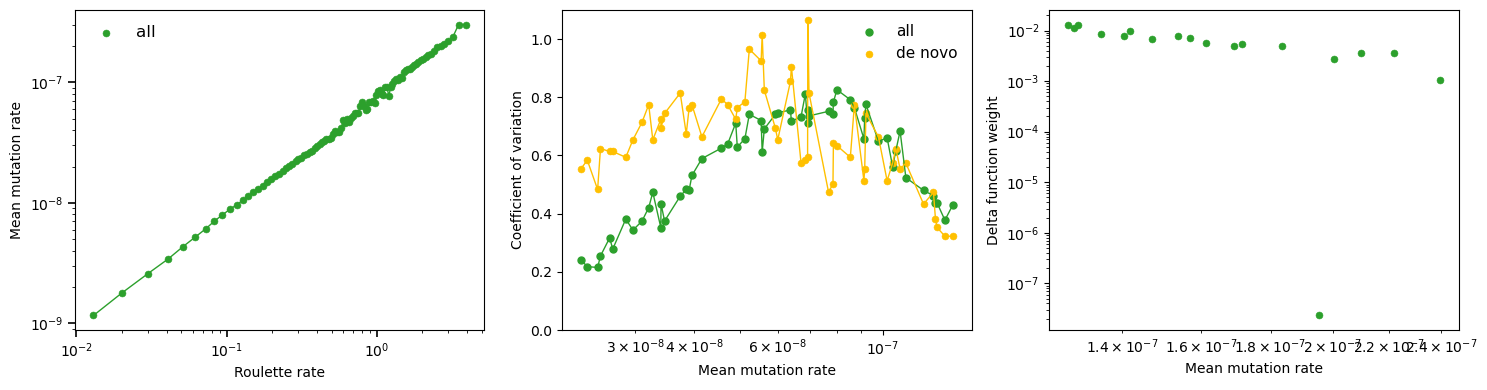

In [ ]:
# Plot the mean mutation rate, residual variance and p_mu as a function of Roulette for all ancestries together

plot_MR_demographies_fixed(demographies=["all"], epoch = 3, fig_save_file="../Figures/all_mut_dist.svg", MR_cv_cutoff=0.29)  # "AMR", "FIN", "SAS", "EAS", "AFR"

In [61]:
def plot_MR_demographies(demographies, epoch=3, figsize=(5, 4), alpha=1, s=25, fig_save_file=None, MR_cv_cutoff=0.211):
    """
    Plot mutation-rate parameters vs MR for multiple ancestries.

    CV panel:
    - Only MR > MR_cv_cutoff are shown
    - De novo CV shown as reference across all bins
    """

    fig, axes = plt.subplots(1, 1, figsize=figsize)
    ax1 = axes #, ax2, ax3 

    # ---------------------------------------------------
    # Load de novo once (for CV reference)
    # ---------------------------------------------------
    df_mu_var_denovo = pd.read_csv("../Mutation_rate_estimation/param_mut_rate/results_mu_var_de_novo.csv")

    for demo in demographies:

        MR, mean_mu, var_mu, p_mu, ll = get_MR_values(demo, epoch=epoch)
        color = ANCESTRY_COLORS.get(demo, "#1f77b4")

        # -------------------------------
        # Panel 1: mean μ vs MR
        # -------------------------------
        ax1.scatter(MR, mean_mu,s=s,color=color,alpha=alpha, linewidth=0.4, label=demo)
        idx = np.argsort(MR)
        # ax1.plot(MR[idx], mean_mu[idx], lw=1, color = color)
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ax1.tick_params(direction="out", length=5, width=1.2)
        

    # ---------------------------------------------------
    # Labels
    # ---------------------------------------------------
    ax1.set_xlabel("Roulette rate")
    ax1.set_ylabel("Mean mutation rate")

    # ax2.set_xlabel("Mean mutation rate")
    # ax2.set_ylabel("Coefficient of variation")

    # ax3.set_xlabel("Mean mutation rate")
    # ax3.set_ylabel("Delta function weight")

    ax1.legend(frameon=False, fontsize=12)
    # ax2.legend(frameon=False, fontsize=11)

    plt.tight_layout()

    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format="svg")

    plt.show()


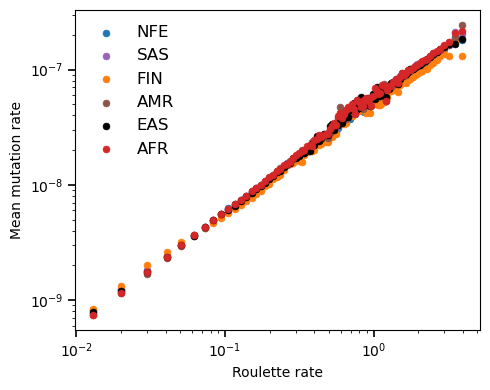

In [ ]:
# Plot the mean mutation rate as a function of Roulette for different ancestries in the same plot

plot_MR_demographies(demographies=["NFE", "SAS", "FIN", "AMR", "EAS", "AFR"], epoch = 3, fig_save_file="../Figures/all_demo_mut_dist.svg")  # "AMR", "FIN", "SAS", "EAS", "AFR"

In [ ]:
# plot the likelihood differences between (1 param and 3 param) and (2 param and 3 param) models as a function of mean mutation rate, for NFE
def plot_LL_diff(mu_low_mu = 2e-10, figsize=(10, 4), alpha=1, s=25, fig_save_file=None, MR_cv_cutoff=0.211):
    """
    Plot Likelihood differences between (1 param and 3 param) and (2 param and 3 param) models .
    """

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax1, ax2 = axes

    df_1param = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_NFE.txt', sep = '\t')
    df_2param = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_NFE.txt', sep = '\t')
    df_3param = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
    
    LL_1param = df_1param['max_loglikelihood'].values
    LL_2param = df_2param['max_loglikelihood'].values
    LL_3param = df_3param['max_loglikelihood'].values

    MR = df_3param["MR"].values
    mean_mus = df_3param['mean_mu'].values/(4*14448)
    var_mus = df_3param['var_mu'].values/((4*14448)**2)
    p_mus = df_3param['p_mu'].values

    mean_mu = (1-p_mus) * mean_mus + p_mus * mu_low_mu
    var_mu = (1-p_mus) * (var_mus + mean_mus**2) + p_mus * mu_low_mu**2 - (mean_mu)**2

    color = ANCESTRY_COLORS.get("NFE", "#1f77b4")

    # -------------------------------
    # Panel 1: 
    # -------------------------------
    # mask_cv = (MR > MR_cv_cutoff) & (MR < 3.5)
    # if np.any(mask_cv):
    mean_mu_short = mean_mu#[mask_cv]
    LL_3_1_short = (LL_3param - LL_1param)#[mask_cv]
    ax1.scatter(mean_mu_short, LL_3_1_short, s=s, color=color, alpha=alpha)
    idx = np.argsort(mean_mu_short)
    # ax1.plot(mean_mu_short[idx], LL_3_1_short[idx], lw=1, color = color)
    # ax1.set_yscale("log")
    ax1.set_xscale("log")
    ax1.tick_params(direction="out", length=5, width=1.2)
    ax1.set_ylim(-25, 450)
    # ax1.set_xlim(0.2, 3.5) 
    # major_ticks = np.array([0.2, 1, 2, 3])
    # ax1.xaxis.set_major_locator(FixedLocator(major_ticks))
    # ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
    # minor_ticks = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
    # ax1.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    # ax1.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
    # ax1.tick_params(axis="x", which="major", length=5, width=1.2)
    # ax1.tick_params(axis="x", which="minor", length=3, width=0.6)
        
    # -------------------------------
    # Panel 3: p_mu vs mean μ
    # -------------------------------
    # mask = (mean_mu>7e-8) & (mean_mu<=1.75e-7) # (mean_mu>1.25e-7) & (mean_mu<3e-7)
    ax2.scatter(mean_mu,#[mask],
                (LL_3param - LL_2param),#[mask], 
                s=s, color=color, alpha=alpha, linewidth=0.4)
    # ax2.set_yscale("log")
    ax2.set_xscale("log")
    ax2.tick_params(direction="out", length=5, width=1.2)
    ax2.set_ylim(-25, 450)
    # ax2.set_xlim(1.2, 3.5)
    # major_ticks = np.array([1.5, 2, 2.5, 3, 3.5])
    # ax2.xaxis.set_major_locator(FixedLocator(major_ticks))
    # ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
    # minor_ticks = np.array([
    #     1.2, 1.3, 1.4, 1.6, 1.7, 1.8, 1.9,
    #     2.1, 2.2, 2.3, 2.4,
    #     2.6, 2.7, 2.8, 2.9,
    #     3.1, 3.2, 3.3, 3.4
    # ])
    # ax2.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    # ax2.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
    # ax2.tick_params(axis="x", which="major", length=5, width=1.2)
    # ax2.tick_params(axis="x", which="minor", length=3, width=0.6)

    # ax2.grid(axis="y", alpha=0.25, linestyle=":")

    # ---------------------------------------------------
    # Labels
    # ---------------------------------------------------
    ax1.set_xlabel("Roulette rate", fontsize = 13)
    ax1.set_ylabel(r"$\Delta \log\left(\frac{L(\alpha, \lambda, p_{low}|k, s = 0, N_{NFE})}{L(\mu_R|k, s = 0, N_{NFE})}\right)$", fontsize = 13)

    ax2.set_xlabel("Roulette rate", fontsize = 13)
    ax2.set_ylabel(r"$\Delta \log\left(\frac{L(\alpha, \lambda, p_{low}|k, s = 0, N_{NFE})}{L(\alpha, \lambda|k, s = 0, N_{NFE})}\right)$", fontsize = 13)

    plt.tight_layout()

    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format="svg")

    plt.show()


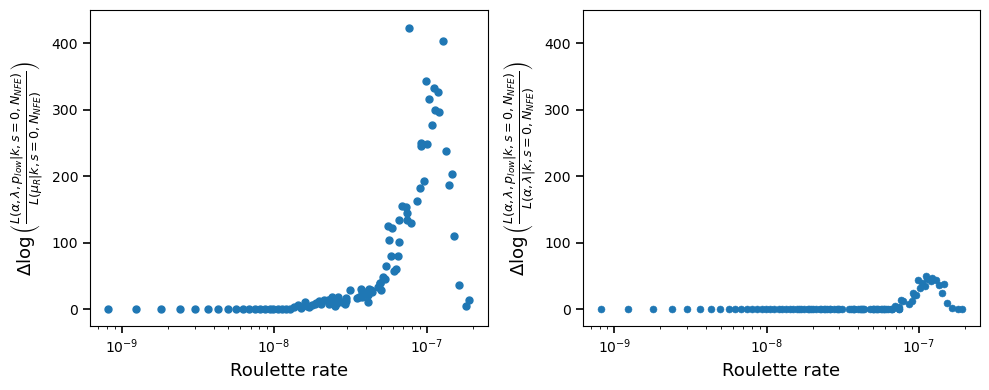

In [26]:
plot_LL_diff(fig_save_file="../Figures/LL_diff_mu.svg")

In [4]:
## Plot prob of segregating sites with mutation rate from 1 param model and 3 param model
# ----------------------------------------------------------
# Fixed ancestry colors: consistent across all figures
# ----------------------------------------------------------
ANCESTRY_COLORS = {
    "NFE":     "#1f77b4",   # blue
    "AFR":     "#d62728",   # red
    "SAS":     "#9467bd",   # purple
    "EAS":     "#000000",   # black
    "AMR":     "#8c564b",   # brown-grey
    "FIN":     "#ff7f0e",   # orange
    "all":     "#2ca02c",   # green
    "de novo": "#FFC000"    # gold/yellow
}


def load_mu_params_for_demography(demography="NFE", epoch = 3, single_param = False):

    if single_param == True:
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_NFE.txt', sep = '\t')
    elif demography == "NFE" or demography == "schraiber_et_al":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
    elif demography == "all":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_all.txt', sep = '\t')
    else:
        df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')
         
    return df_mu_var_p
    

def load_demography_result(json_file, demography, epoch_no):
    with open(json_file, "r") as f:
        records = json.load(f)
    for rec in records:
        if rec["demography"] == demography and rec["epoch_no"] == epoch_no:
            return rec
        else:
            rec = {"params" : []}
    return rec
    

def compute_predicted_SFS_for_MR(row_mu, demography, params_dem, mu_low_mu, AN, kmax=0):
    mean_mu = row_mu["mean_mu"]
    var_mu  = row_mu["var_mu"]
    p_mu    = row_mu["p_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography="NFE", n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography="NFE", n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    else:

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography=demography, n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography=demography, n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    
    # Mixture of gamma-based SFS and low-mu SFS
    SFS_mix = (1 - p_mu) * SFS_gamma + p_mu * SFS_low_mu

    return SFS_mix


def compute_predicted_SFS_for_MR_1param(row_mu, demography, params_dem, AN, kmax=0):
    mean_mu = row_mu["mean_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography="NFE", n=AN, params=params_dem, model="original", kmax=kmax)

    else:

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography=demography, n=AN, params=params_dem, model="original", kmax=kmax)

    return SFS_pred

# ------------------------------------------------------------
# Tick formatter like your example: 10^-1, 1/2, 1-10^-k
# ------------------------------------------------------------
def _p_formatter(y, _):
    if np.isclose(y, 0.5):
        return r"$\frac{1}{2}$"

    if y > 0.5:
        d = 1.0 - y
        if d > 0:
            k = int(round(-np.log10(d)))
            if np.isclose(d, 10 ** (-k), rtol=0, atol=1e-12):
                return rf"$1-10^{{-{k}}}$"
        return f"{y:.2g}"

    if y > 0:
        k = int(round(-np.log10(y)))
        if np.isclose(y, 10 ** (-k), rtol=0, atol=1e-12):
            return rf"$10^{{-{k}}}$"

    return f"{y:.2g}"
    
def plot_prop_segregating_all_MR(demography, epoch_no, json_file="../Demography_estimation/demography_results.json", mu_low_mu=2e-10, fig_save_file=None):
    # -----------------------------
    # Load data + parameters
    # -----------------------------
    df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression="gzip")

    df_mu_3 = load_mu_params_for_demography(demography=demography, epoch=epoch_no, single_param=False)
    df_mu_1 = load_mu_params_for_demography(demography=demography, epoch=epoch_no, single_param=True)

    # Ensure sorted + aligned by MR
    df_mu_3 = df_mu_3.sort_values("MR").reset_index(drop=True)
    df_mu_1 = df_mu_1.sort_values("MR").reset_index(drop=True)

    MR_vals = np.intersect1d(df_mu_3["MR"].values, df_mu_1["MR"].values)
    # MR_vals = MR_vals[15:-2]
    df_mu_3 = df_mu_3[df_mu_3["MR"].isin(MR_vals)].sort_values("MR").reset_index(drop=True)
    df_mu_1 = df_mu_1[df_mu_1["MR"].isin(MR_vals)].sort_values("MR").reset_index(drop=True)

    mean_mus = df_mu_3['mean_mu'].values/(4*14448)
    p_mus = df_mu_3['p_mu'].values
    mean_mu = (1-p_mus) * mean_mus + p_mus * mu_low_mu

    # Demography params
    params_rec = load_demography_result(json_file, demography, epoch_no)
    params_dem = params_rec.get("params", [])

    # Use AN (assumed constant per demography)
    if demography == "all":
        AN = df_syn["allele_number"].mode().iloc[0]
    elif demography == "schraiber_et_al":
        AN = df_syn["AN_NFE"].mode().iloc[0]
    else:
        AN = df_syn[f"AN_{demography}"].mode().iloc[0]

    # -----------------------------
    # Observed p(seg) per MR
    # -----------------------------
    obs_pseg = []
    for MR in MR_vals:
        df_bin = df_syn[df_syn["MR"] == MR]

        if demography == "all":
            ac = df_bin["allele_count"].to_numpy()
        elif demography == "schraiber_et_al":
            ac = df_bin["AC_NFE"].to_numpy()
        else:
            ac = df_bin[f"AC_{demography}"].to_numpy()

        # proportion segregating = fraction with k > 0
        obs_pseg.append(np.mean(ac > 0))

    obs_pseg = np.array(obs_pseg, dtype=float)

    # -----------------------------
    # Predicted p(seg) per MR
    # (compute kmax=0 => returns SFS[0] = P(k=0))
    # -----------------------------
    pred1_pseg = np.empty(len(MR_vals), dtype=float)
    pred3_pseg = np.empty(len(MR_vals), dtype=float)

    for i in range(len(MR_vals)):
        MR = MR_vals[i]

        # 1-param: point mass at mean_mu
        row1 = df_mu_1[df_mu_1["MR"] == MR].iloc[0]
        SFS0_1 = compute_predicted_SFS_for_MR_1param(
            row1, demography, params_dem, AN, kmax=0
        )[0]
        pred1_pseg[i] = 1 - SFS0_1

        # 3-param: mixture gamma + low-mu
        row3 = df_mu_3[df_mu_3["MR"] == MR].iloc[0]
        SFS0_3 = compute_predicted_SFS_for_MR(
            row3, demography, params_dem, mu_low_mu, AN, kmax=0
        )[0]
        pred3_pseg[i] = 1 - SFS0_3

    mu_x = mean_mu
    p_obs = obs_pseg
    p1   = pred1_pseg
    p3   = pred3_pseg
    
    # sort by mu_x
    order = np.argsort(mu_x)
    mu_x = mu_x[order]
    p_obs = p_obs[order]
    p1 = p1[order]
    p3 = p3[order]

    # clip away from 0/1 for logit stability
    eps = 1e-6
    p_obs = np.clip(p_obs, eps, 1 - eps)
    p1    = np.clip(p1,    eps, 1 - eps)
    p3    = np.clip(p3,    eps, 1 - eps)

    # colors
    blue = ANCESTRY_COLORS.get("NFE", "#1f77b4")     # observed style (blue)
    orange = "#E66100"                               # nice orange for expected curve

    # ---------- plot ----------
    fig, ax = plt.subplots(figsize=(5.8, 4.4))

    # observed: line + points
    # ax.plot(mu_x, p_obs, color=blue, lw=2.4, zorder=2, label="Observed gnomAD v4")
    ax.scatter(mu_x, p_obs, color=blue, s=20, zorder=3, label="Observed gnomAD v4")

    # expected under zero residual variance (1-param): thick orange
    ax.plot(mu_x, p1, color=orange, lw=2, zorder=1, label="Expected - No residual variance")
    ax.plot(mu_x, p3, color=blue, lw=2, zorder=1, label="Expected - With residual variance")

    # # residual variance gap: between p1 and p3
    # ax.fill_between(mu_x, p1, p3, color="0.75", alpha=0.7, zorder=0)

    # # CpG cutoff + shading
    # ax.axvline(cpg_cutoff_mu, color="k", ls="--", lw=2.2)
    # if shade_right:
    #     ax.axvspan(cpg_cutoff_mu, mu_x.max(), color="0.85", zorder=-1)

    # axes
    ax.set_xscale("log")
    ax.set_yscale("logit")

    # y ticks like the example
    yticks = np.array([1e-1, 0.5, 1 - 1e-1, 1 - 1e-2, 1 - 1e-3])
    ax.yaxis.set_major_locator(FixedLocator(yticks))
    ax.yaxis.set_major_formatter(FuncFormatter(_p_formatter))

    # labels
    ax.set_xlabel("Mutation rate (Roulette)", fontsize=13)
    ax.set_ylabel("Proportion of segregating sites", fontsize=13)

    # styling
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=6, width=1.2)
    # ax.grid(alpha=0.18, which="both")

    # # legend with patches (like your example)
    # handles = [
    #     Patch(facecolor=blue, edgecolor="none", label="Observed gnomAD v4"),
    #     Patch(facecolor=orange, edgecolor="none", label="Expected under zero\nresidual variance"),
    #     Patch(facecolor="0.75", edgecolor="0.55", label="Expected with residual\nvariance "),
    # ]
    # ax.legend(handles=handles, frameon=False, fontsize=12, loc="upper left")
    ax.legend(frameon=False, fontsize=12, loc="upper left")

    plt.tight_layout()
    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format="svg")
    plt.show()

    # Return table for downstream use
    out = pd.DataFrame({
        "MR": MR_vals,
        "pseg_observed": obs_pseg,
        "pseg_pred_1param": pred1_pseg,
        "pseg_pred_3param": pred3_pseg,
    })
    return out



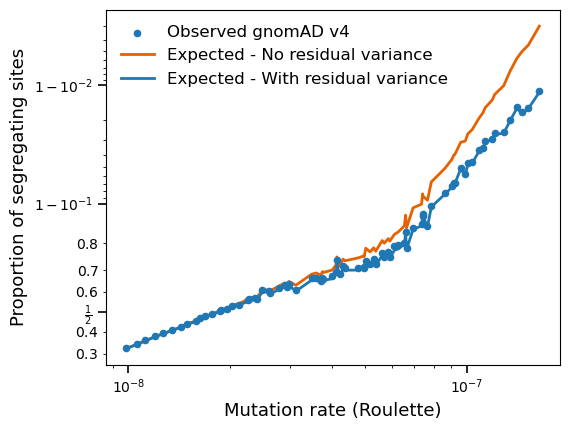

In [19]:
out = plot_prop_segregating_all_MR(demography = "NFE", epoch_no = 3, json_file="../Demography_estimation/demography_results.json", mu_low_mu=2e-10, fig_save_file="../Figures/prob_seg.svg")

In [6]:
out.to_csv("prob_seg.txt.gz", sep="\t", index=False, compression="gzip")